C:\Users\tuand\AppData\Local\Temp\ipykernel_24360\647015200.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Phase', y='mean', data=latency_stats, palette=['#e74c3c', '#2ecc71'], width=0.5)


✅ Đã xuất chart_1_latency_comparison.png


C:\Users\tuand\AppData\Local\Temp\ipykernel_24360\647015200.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Phase', y='latency', data=df, palette=['#e74c3c', '#2ecc71'], width=0.5, showfliers=False)


✅ Đã xuất chart_2_latency_distribution.png
✅ Đã xuất chart_3_quality_breakdown.png

--- TÓM TẮT KẾT QUẢ ---
                  mean       std   min    max
Phase                                        
Phase 1 (Old)  7.14075  4.931034  0.16  23.94
Phase 2 (New)  2.71960  1.569547  0.00   8.16


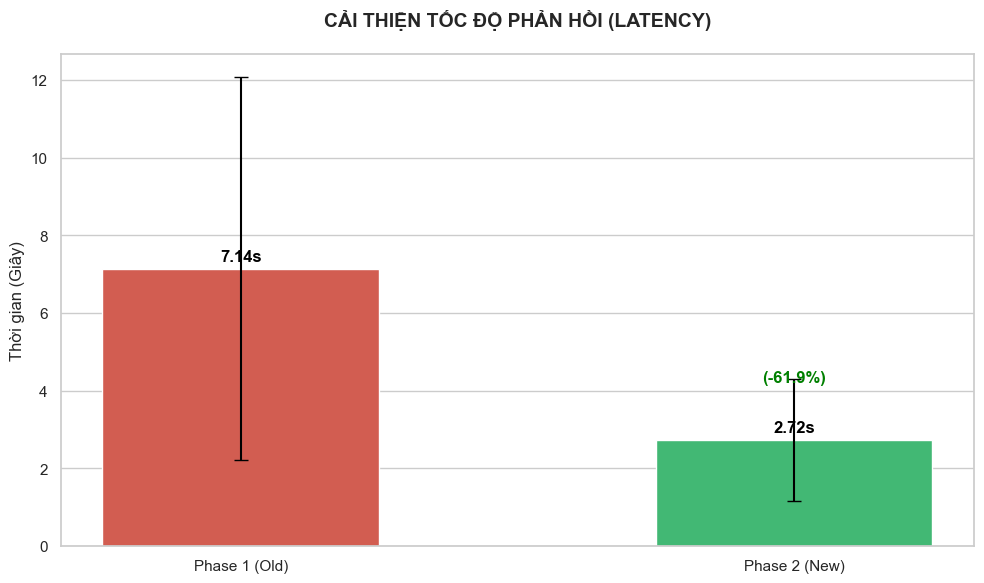

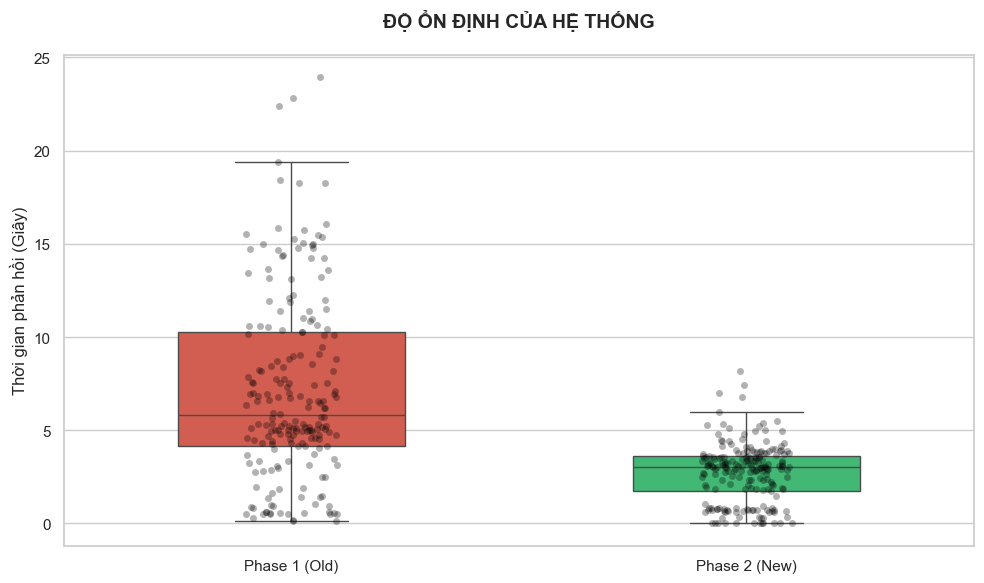

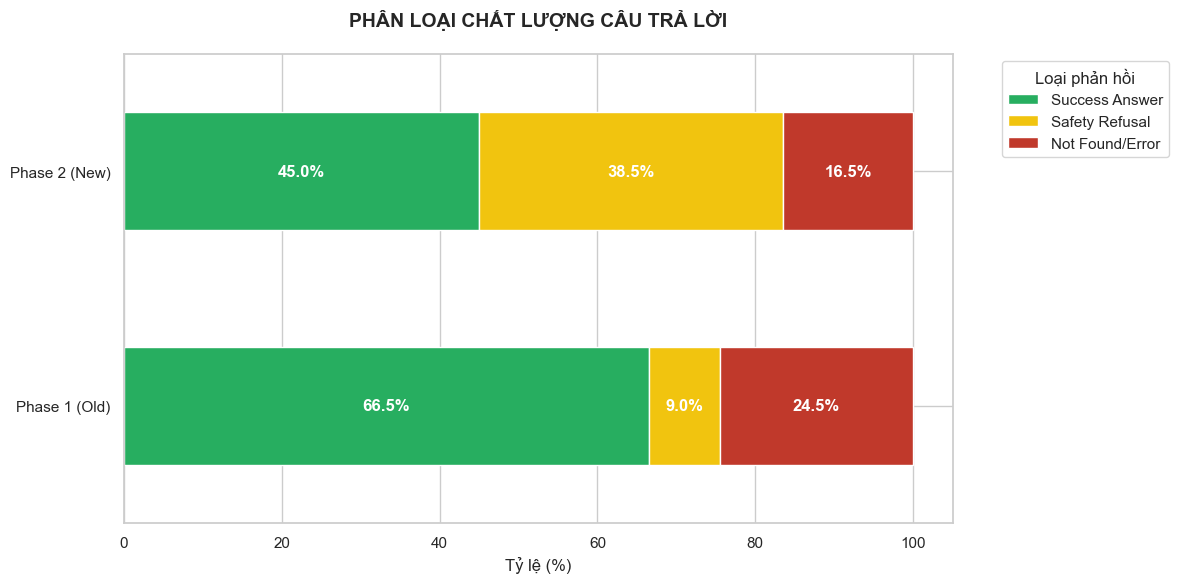

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CẤU HÌNH GIAO DIỆN BIỂU ĐỒ ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
# Nếu bị lỗi font tiếng Việt, hãy đổi sang 'Arial' hoặc font hỗ trợ
# plt.rcParams['font.sans-serif'] = ['Arial'] 

# --- 2. HÀM PHÂN LOẠI CÂU TRẢ LỜI (LOGIC ĐÁNH GIÁ) ---
def categorize_response(row):
    text = str(row['response']).lower()
    input_text = str(row['input']).lower()
    
    # Các từ khóa xác định câu trả lời an toàn (Safety Guardrail)
    safety_keywords = [
        "tôi chỉ là trợ lý", "không có chuyên môn", "từ chối", 
        "lăng mạ", "xúc phạm", "ngoài phạm vi", "không thể trả lời"
    ]
    
    # Các từ khóa xác định không tìm thấy (Not Found/Error)
    error_keywords = [
        "không tìm thấy", "không xác định", "xin lỗi, tôi không thể", 
        "lỗi", "error", "❌"
    ]
    
    # Logic phân loại
    if any(kw in text for kw in safety_keywords):
        return "Safety Refusal" # Từ chối an toàn
    elif any(kw in text for kw in error_keywords):
        return "Not Found/Error" # Không tìm thấy
    else:
        return "Success Answer" # Trả lời thành công (RAG hoạt động)

# --- 3. LOAD VÀ XỬ LÝ DỮ LIỆU ---
def load_data():
    try:
        with open('test_report.json', 'r', encoding='utf-8') as f:
            data_p1 = json.load(f)
        with open('test_again_V2.json', 'r', encoding='utf-8') as f:
            data_p2 = json.load(f)
            
        df1 = pd.DataFrame(data_p1['details'])
        df1['Phase'] = 'Phase 1 (Old)'
        
        df2 = pd.DataFrame(data_p2['details'])
        df2['Phase'] = 'Phase 2 (New)'
        
        # Gộp data
        df_full = pd.concat([df1, df2])
        
        # Áp dụng phân loại
        df_full['Category'] = df_full.apply(categorize_response, axis=1)
        
        return df_full
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file json. Hãy đảm bảo file nằm cùng thư mục.")
        return None

# --- 4. VẼ BIỂU ĐỒ ---
def plot_charts(df):
    if df is None: return

    # --- BIỂU ĐỒ 1: SO SÁNH ĐỘ TRỄ (LATENCY) ---
    plt.figure(figsize=(10, 6))
    
    # Tính toán chỉ số
    latency_stats = df.groupby('Phase')['latency'].agg(['mean', 'max', 'std']).reset_index()
    
    # Vẽ Bar Chart
    bar_plot = sns.barplot(x='Phase', y='mean', data=latency_stats, palette=['#e74c3c', '#2ecc71'], width=0.5)
    
    # Thêm thanh sai số (Error bar) minh họa độ ổn định (Standard Deviation)
    plt.errorbar(x=range(len(latency_stats)), y=latency_stats['mean'], 
                 yerr=latency_stats['std'], fmt='none', c='black', capsize=5)

    # Label
    plt.title('CẢI THIỆN TỐC ĐỘ PHẢN HỒI (LATENCY)', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Thời gian (Giây)', fontsize=12)
    plt.xlabel('')
    
    # Hiển thị số liệu trên cột
    for index, row in latency_stats.iterrows():
        bar_plot.text(index, row['mean'] + 0.2, f"{row['mean']:.2f}s", 
                      color='black', ha="center", fontweight='bold', fontsize=12)
        # Hiển thị mức cải thiện
        if "Phase 2" in row['Phase']:
            improvement = (1 - row['mean'] / latency_stats.iloc[0]['mean']) * 100
            bar_plot.text(index, row['mean'] + 1.5, f"(-{improvement:.1f}%)", 
                          color='green', ha="center", fontweight='bold')

    plt.tight_layout()
    plt.savefig('chart_1_latency_comparison.png', dpi=300)
    print("✅ Đã xuất chart_1_latency_comparison.png")

    # --- BIỂU ĐỒ 2: PHÂN BỐ ĐỘ ỔN ĐỊNH (BOX PLOT) ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Phase', y='latency', data=df, palette=['#e74c3c', '#2ecc71'], width=0.5, showfliers=False)
    sns.stripplot(x='Phase', y='latency', data=df, color='black', alpha=0.3, jitter=True) # Hiện điểm dữ liệu thật
    
    plt.title('ĐỘ ỔN ĐỊNH CỦA HỆ THỐNG', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Thời gian phản hồi (Giây)', fontsize=12)
    plt.xlabel('')
    
    plt.tight_layout()
    plt.savefig('chart_2_latency_distribution.png', dpi=300)
    print("✅ Đã xuất chart_2_latency_distribution.png")

    # --- BIỂU ĐỒ 3: CHẤT LƯỢNG CÂU TRẢ LỜI (STACKED BAR) ---
    # Tính toán tỷ lệ
    quality_counts = df.groupby(['Phase', 'Category']).size().reset_index(name='Count')
    total_counts = df.groupby('Phase')['id'].count().reset_index(name='Total')
    quality_merged = pd.merge(quality_counts, total_counts, on='Phase')
    quality_merged['Percentage'] = (quality_merged['Count'] / quality_merged['Total']) * 100
    
    # Pivot để vẽ stacked bar
    pivot_df = quality_merged.pivot(index='Phase', columns='Category', values='Percentage').fillna(0)
    # Sắp xếp lại thứ tự cột cho đẹp
    cols_order = ['Success Answer', 'Safety Refusal', 'Not Found/Error']
    pivot_df = pivot_df[cols_order]

    # Vẽ
    ax = pivot_df.plot(kind='barh', stacked=True, color=['#27ae60', '#f1c40f', '#c0392b'], figsize=(12, 6))
    
    plt.title('PHÂN LOẠI CHẤT LƯỢNG CÂU TRẢ LỜI', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Tỷ lệ (%)', fontsize=12)
    plt.ylabel('')
    plt.legend(title='Loại phản hồi', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Hiển thị % trên thanh
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig('chart_3_quality_breakdown.png', dpi=300)
    print("✅ Đã xuất chart_3_quality_breakdown.png")

# --- MAIN ---
if __name__ == "__main__":
    df = load_data()
    if df is not None:
        plot_charts(df)
        print("\n--- TÓM TẮT KẾT QUẢ ---")
        stats = df.groupby('Phase')['latency'].describe()
        print(stats[['mean', 'std', 'min', 'max']])